In [33]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_state_city, plot_state_qsphere, plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
n = 2
def deutsch_jozsa_oracle(case='balanced'):
    oracle = QuantumCircuit(3)
    if case == 'balanced':
        oracle.cx(0, 2)
        oracle.cx(1, 2)
    elif case == 'constant':
        pass
    return oracle

def deutsch_jozsa_circuit_no_measure(oracle):
    dj = QuantumCircuit(3)
    dj.x(2)
    dj.h([0, 1, 2])
    dj.append(oracle.to_gate(label="U_f"), [0, 1, 2])
    dj.h([0, 1])
    return dj

def deutsch_jozsa_circuit(oracle):
    dj = deutsch_jozsa_circuit_no_measure(oracle)
    dj.measure_all()
    return dj

Deutsch–Jozsa Circuit:


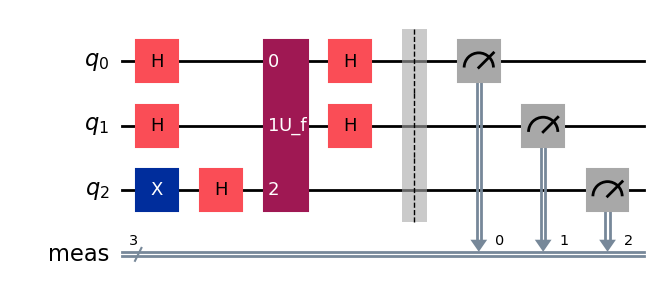

In [34]:
oracle = deutsch_jozsa_oracle('balanced')   # 'constant' or 'balanced'
dj_circuit = deutsch_jozsa_circuit(oracle)

print("Deutsch–Jozsa Circuit:")
display(dj_circuit.draw('mpl'))


Measurement Results: {'111': 515, '011': 509}


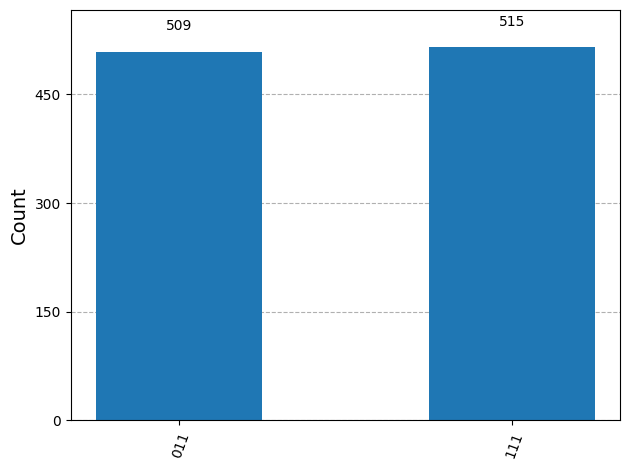

In [35]:
simulator = AerSimulator()
compiled_circuit = transpile(dj_circuit, simulator)
job = simulator.run(compiled_circuit)
result = job.result()
counts = result.get_counts()
print("Measurement Results:", counts)

display(plot_histogram(counts))

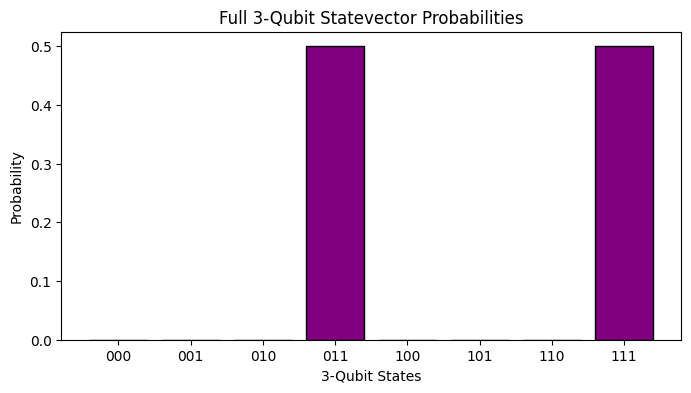

In [36]:
basis_states = ['000','001','010','011','100','101','110','111']
probabilities = np.abs(state.data)**2

plt.figure(figsize=(8,4))
plt.bar(basis_states, probabilities, color='purple', edgecolor='black')
plt.xlabel("3-Qubit States")
plt.ylabel("Probability")
plt.title("Full 3-Qubit Statevector Probabilities")
plt.show()

Statevector: Statevector([ 1.35805827e-35+0.j,  6.73463194e-18+0.j,  4.40052725e-19+0.j,
              7.07106781e-01+0.j, -1.35805827e-35+0.j, -6.73463194e-18+0.j,
             -4.40052725e-19+0.j, -7.07106781e-01+0.j],
            dims=(2, 2, 2))


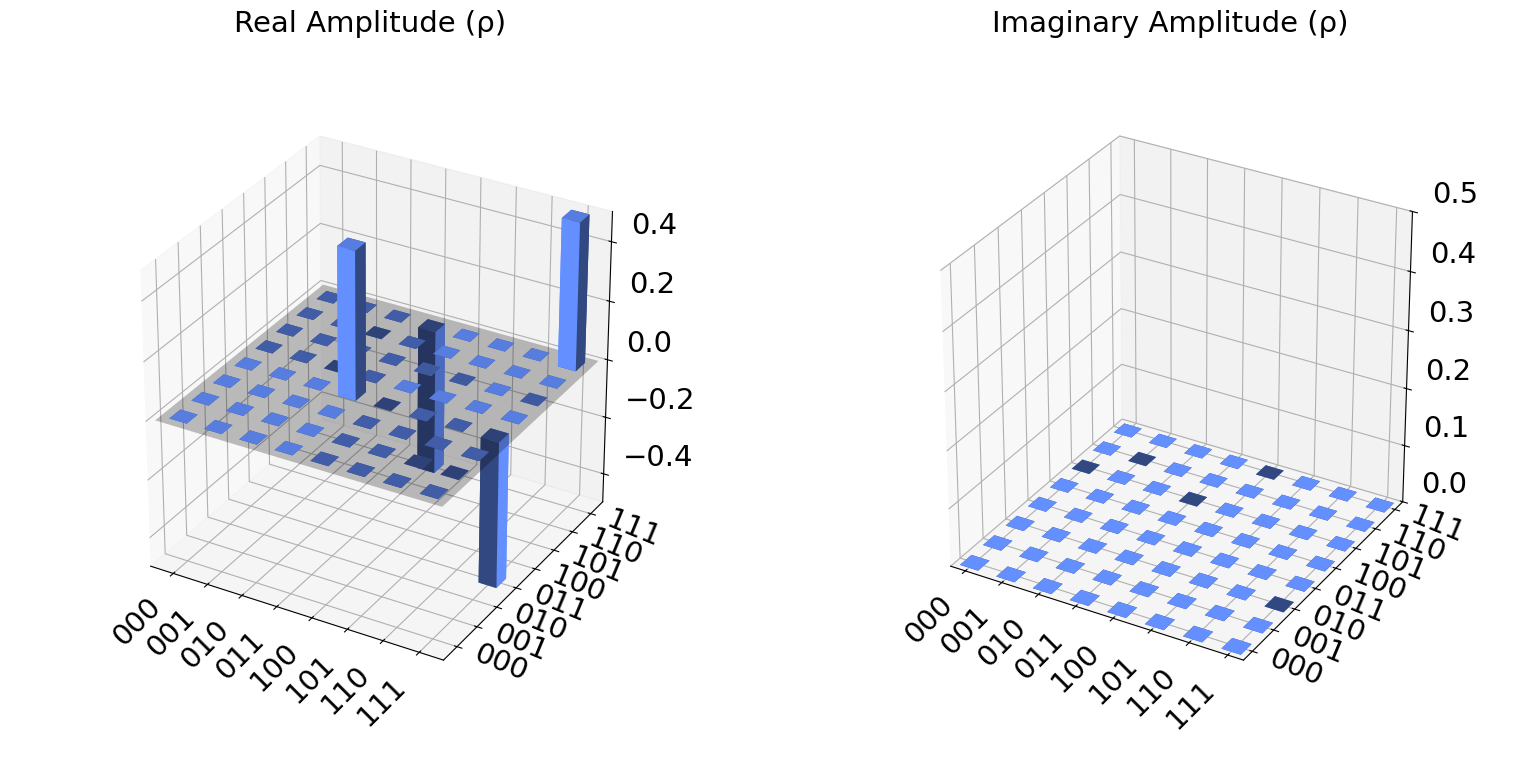

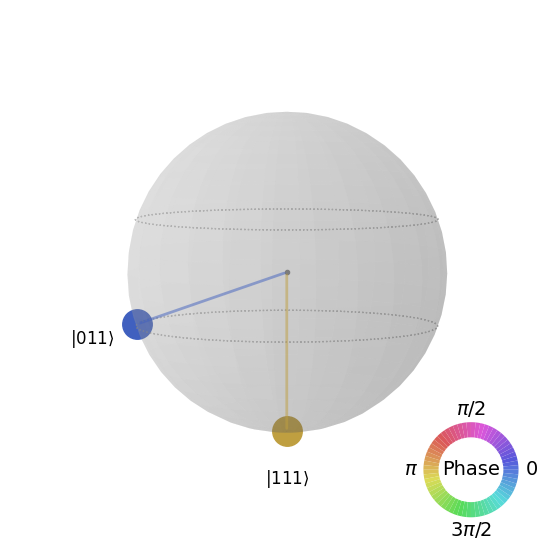

In [37]:
dj_no_measure = QuantumCircuit(3)
dj_no_measure.x(2)
dj_no_measure.h([0, 1, 2])
dj_no_measure.append(oracle.to_gate(label="U_f"), [0, 1, 2])
dj_no_measure.h([0, 1])
state = Statevector.from_instruction(dj_no_measure)
print("Statevector:", state)
display(plot_state_city(state))
display(plot_state_qsphere(state))

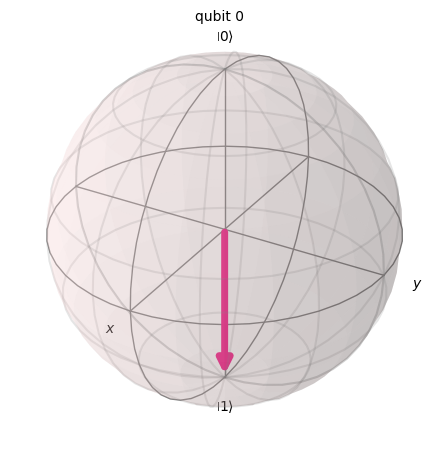

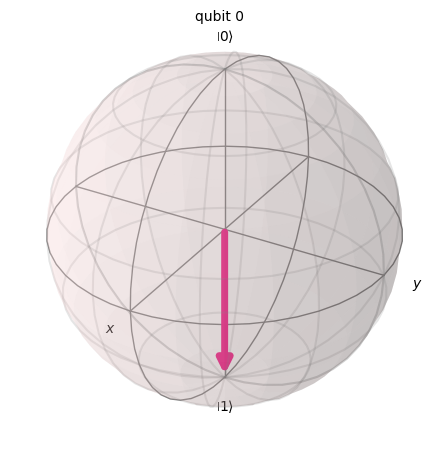

In [38]:
dm = DensityMatrix(state)
for q in [0, 1]:
    rho_q = partial_trace(dm, [i for i in range(3) if i != q])
    display(plot_bloch_multivector(rho_q.data))

In [39]:
if '0' * n in counts and len(counts) == 1:
    print("Function is CONSTANT: All measurement results are |0...0>")
else:
    print("Function is BALANCED: Measurements include states other than |0...0>")

Function is BALANCED: Measurements include states other than |0...0>
